# ***AEROFIT Business Case Study***


### Phase 1: Importing aerofit_treadmill.csv Dataset

In [ ]:
!gdown 1EmyoBhy3oU2RHMbSog4VO6qs5yPBqmH5 -O aerofit.csv

Downloading...
From: https://drive.google.com/uc?id=1EmyoBhy3oU2RHMbSog4VO6qs5yPBqmH5
To: /content/aerofit.csv
100% 7.28k/7.28k [00:00<00:00, 17.3MB/s]


### Phase 2: Importing Required Libraries


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Phase 3: Reading the Dataset into Data Frame

In [ ]:
atm = pd.read_csv('aerofit.csv')
atm

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


In [ ]:
atm.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
atm.tail()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120
179,KP781,48,Male,18,Partnered,4,5,95508,180


### Phase 4: Understanding the Datset

In [ ]:
atm.shape

(180, 9)

In [ ]:
#  The Aerofit Dataset consists of 180 Rows and 9 Columns

In [ ]:
# Columns in the Dataset
atm.columns

Index(['Product', 'Age', 'Gender', 'Education', 'MaritalStatus', 'Usage',
       'Fitness', 'Income', 'Miles'],
      dtype='object')

In [ ]:
atm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [ ]:
# The dataset has 3 columns which are Objects, i.e. Product, Gender, MaritalStatus, they can be converted to categories for further Data Analysis

In [ ]:
from pandas.core.indexes import category
cat_cols = ['Product', 'Gender', 'MaritalStatus']
for col in cat_cols:
  atm[col] = atm[col].astype('category')

In [ ]:
atm.describe(include = 'all')

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
count,180,180.000000,180,180.000000,180,180.000000,180.000000,180.000000,180.000000
unique,3,NaN,2,NaN,2,NaN,NaN,NaN,NaN
top,KP281,NaN,Male,NaN,Partnered,NaN,NaN,NaN,NaN
freq,80,NaN,104,NaN,107,NaN,NaN,NaN,NaN
mean,NaN,28.788889,NaN,15.572222,NaN,3.455556,3.311111,53719.577778,103.194444
std,NaN,6.943498,NaN,1.617055,NaN,1.084797,0.958869,16506.684226,51.863605
min,NaN,18.000000,NaN,12.000000,NaN,2.000000,1.000000,29562.000000,21.000000
25%,NaN,24.000000,NaN,14.000000,NaN,3.000000,3.000000,44058.750000,66.000000
50%,NaN,26.000000,NaN,16.000000,NaN,3.000000,3.000000,50596.500000,94.000000
75%,NaN,33.000000,NaN,16.000000,NaN,4.000000,4.000000,58668.000000,114.750000


### Phase 5: Handle Missing Values

In [ ]:
atm.isnull().sum()

,0
Product,0
Age,0
Gender,0
Education,0
MaritalStatus,0
Usage,0
Fitness,0
Income,0
Miles,0


In [ ]:
# Tha Datset is clean, Any Column or Row does not contains any null or missing values.

In [ ]:
atm.duplicated().sum()

np.int64(0)

In [ ]:
# Tha Datset does not contains any repeating records.

### Phase 6: Non Graphical Analysis

In [ ]:
atm['Age'].min(), atm['Age'].max()

(18, 50)

In [ ]:
# The youngest Customer is of the age 18 and the oldest is aged 50.

In [ ]:
age_bins = [13, 19, 29, 39, 49, 59]
age_labels = ['Teenage', '20s', '30s', '40s', '50s']
atm['Age_Group'] = pd.cut(atm['Age'], bins = age_bins, labels = age_labels)
atm.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Teenage
1,KP281,19,Male,15,Single,2,3,31836,75,Teenage
2,KP281,19,Female,14,Partnered,4,3,30699,66,Teenage
3,KP281,19,Male,12,Single,3,3,32973,85,Teenage
4,KP281,20,Male,13,Partnered,4,2,35247,47,20s


In [ ]:
atm['Age_Group'].value_counts()

,count
Age_Group,
20s,108
30s,50
40s,16
Teenage,5
50s,1


In [ ]:
# Aerofit has attracted customers aged in their 20's dominantly, it states that the
# most health consious customers who use Aerofit Products are under 30 in age.

In [ ]:
atm['Product'].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


In [ ]:
# Majority of customers have bought KP281 Product, which suggests KP281 is mostly preferred by customers, as It is entry level and is for beginners.
# whereas KP781 is least bought by customers, irrespective of the Gender, Marital Status, It does provides advanced features, but may not be user friendly,
  # as it id for the KP281.

In [ ]:
atm['Gender'].value_counts()

,count
Gender,
Male,104
Female,76


In [ ]:
# Aerofit products attracted Male Gender dominant Customers than Female ones, across all types of Treadmill products.

In [ ]:
atm['MaritalStatus'].value_counts()

,count
MaritalStatus,
Partnered,107
Single,73


In [ ]:
# Arofit products attract married, co living customers more than single ones.

In [ ]:
atm['Product'].value_counts(normalize = True)

,proportion
Product,
KP281,0.444444
KP481,0.333333
KP781,0.222222


In [ ]:
# Almost 45% of Arofit Customers preferred KP281, 33% preferred KP481 and 22% preferred KP781

In [ ]:
atm['Gender'].value_counts(normalize = True)

,proportion
Gender,
Male,0.577778
Female,0.422222


In [ ]:
# Male Customers (58%) use Aerofit Products more than Female ones (42%), across all age, marital status, fitness category.
# Aerofit has attracted both Male and female customers approximately. But Male dominate in usage.

In [ ]:
atm['MaritalStatus'].value_counts(normalize = True)

,proportion
MaritalStatus,
Partnered,0.594444
Single,0.405556


In [ ]:
# 59% of Aerofit Customers are partnered, and remaing 41% are Single.

In [ ]:
# For all Numerical Columns, Let us Describe them to get a idea of the Statistics

In [ ]:
atm.head(1)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Teenage


In [ ]:
atm[['Age', 'Education', 'Usage', 'Fitness', 'Income', 'Miles']].describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


In [ ]:
# From the above analysis, We can deduce the following:
# The customers Ages ranges from 18 to 50, which means all the targeted customers are Adults.
# The Mean 28.79 and median 26 for Age suggests that, there is not much of a variance
  # of data in Age of customers, showing uniformity, less skewness in data arrangement.
# The average no. ofg times customers planned to use the Treadmills ranges from 2 to 7 times.
  # Most of the customers plan to use more than 3 times in a week
# Fitness of customers in a scale of 1 - 5 suggests that, 75% of them have rated below 4,
  # and correspondingly there no. of usage shall be high


In [ ]:
atm['Fitness'].value_counts()

,count
Fitness,
3,97
5,31
2,26
4,24
1,2


In [ ]:
# Among Aerofit customers who have self Rated in scales of 1 to 5, Maximum no. of customers are rated 3, 97 customers, followed by rating 5 and 2.
# There are 2 customers who are in Poor shape (rating 1) and 31 customers who are in excellent shape (rating 5).

In [ ]:
pd.crosstab(index = [atm['Gender'], atm['Product']], columns = atm['Age'], margins = True)

Age             18  19  20  21  22  23  24  25  26  27  ...  41  42  43  44  \
Gender Product                                          ...                   
Female KP281     0   1   1   2   3   3   3   4   3   2  ...   0   0   0   1   
       KP481     0   0   1   1   0   3   2   5   2   0  ...   0   0   0   0   
       KP781     0   0   0   0   0   1   1   1   1   0  ...   0   0   0   0   
Male   KP281     1   2   1   2   1   5   2   3   4   1  ...   1   0   1   0   
       KP481     0   1   2   2   0   4   1   6   1   1  ...   0   0   0   0   
       KP781     0   0   0   0   3   2   3   6   1   3  ...   0   1   0   0   
All              1   4   5   7   7  18  12  25  12   7  ...   1   1   1   1   

Age             45  46  47  48  50  All  
Gender Product                           
Female KP281     0   1   0   0   1   40  
       KP481     0   0   0   0   0   29  
       KP781     0   0   0   0   0    7  
Male   KP281     0   0   1   0   0   40  
       KP481     1   0   0   1   0   31  
       KP781     1   0   1   1   0   33  
All              2   1   2   2   1  180  

[7 rows x 33 columns]

In [ ]:
# The above crosstab shows the no. of customers acroos different age who use different aerofit Treadmill Products.
#

In [ ]:
pd.crosstab(index = [atm['Product'], atm['Fitness']], columns = [atm['Gender'], atm['MaritalStatus']], margins = True)

Gender             Female             Male         All
MaritalStatus   Partnered Single Partnered Single     
Product Fitness                                       
KP281   1               0      0         1      0    1
        2               7      3         4      0   14
        3              18      8        13     15   54
        4               1      2         3      3    9
        5               1      0         0      1    2
KP481   1               0      1         0      0    1
        2               2      4         5      1   12
        3              12      6        13      8   39
        4               1      3         3      1    8
KP781   3               0      1         1      2    4
        4               0      1         5      1    7
        5               4      1        13     11   29
All                    46     30        61     43  180

In [ ]:
pd.crosstab(index = [atm['Gender'], atm['MaritalStatus']], columns = [atm['Product'], atm['Fitness']], margins = True)

Product              KP281               KP481            KP781         All
Fitness                  1   2   3  4  5     1   2   3  4     3  4   5     
Gender MaritalStatus                                                       
Female Partnered         0   7  18  1  1     0   2  12  1     0  0   4   46
       Single            0   3   8  2  0     1   4   6  3     1  1   1   30
Male   Partnered         1   4  13  3  0     0   5  13  3     1  5  13   61
       Single            0   0  15  3  1     0   1   8  1     2  1  11   43
All                      1  14  54  9  2     1  12  39  8     4  7  29  180

In [ ]:
pd.crosstab(index = [atm['Gender'], atm['MaritalStatus']], columns = [atm['Fitness']], margins = True)

Fitness               1   2   3   4   5  All
Gender MaritalStatus                        
Female Partnered      0   9  30   2   5   46
       Single         1   7  15   6   1   30
Male   Partnered      1   9  27  11  13   61
       Single         0   1  25   5  12   43
All                   2  26  97  24  31  180

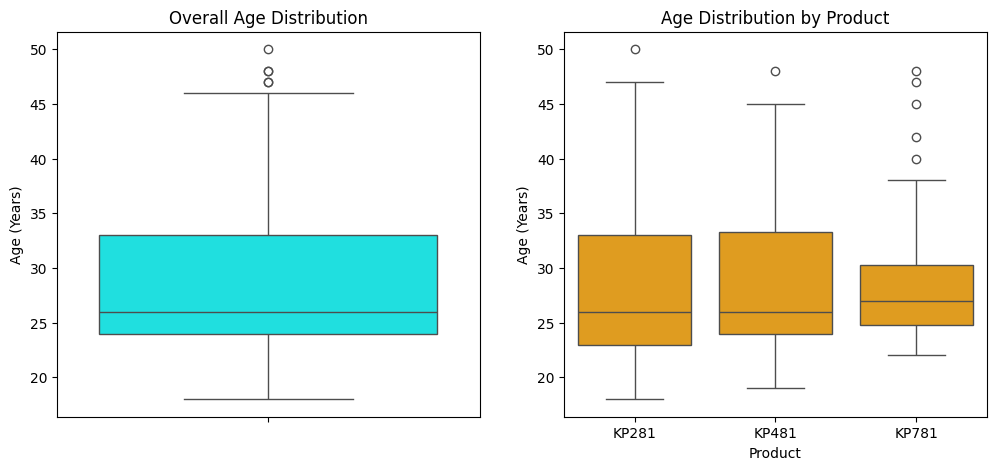

In [ ]:
plt.figure(figsize = (12, 5))

plt.subplot(1,2,1)
abp = sns.boxplot(y = atm['Age'], color = 'cyan')

plt.title('Overall Age Distribution')
plt.ylabel('Age (Years)')

plt.subplot(1,2,2)
apbp = sns.boxplot(y = atm['Age'], x = atm['Product'], color = 'orange')
plt.title('Age Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Age (Years)')

plt.show()

In [ ]:
# From the above Boxplots, the overall Average for Customers age is around 26.

In [ ]:
p_g = pd.crosstab(atm['Product'], atm['Gender'])
p_g

Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


In [ ]:
# The above analysis shows Genderwise Product purchase, KP281 is most common among both Genders.
# We can say that KP281 is beginner friendly, entry level treadmill, lowest in Price i.e. $1500 is mostly prefereed by anyoone.
# Whereas, KP781 available with advanced features and is also costlier in price, is least preferred among any gender.

### Phase 7: Graphical Analysis (Univariate)

In [ ]:
atm.head(1)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Teenage


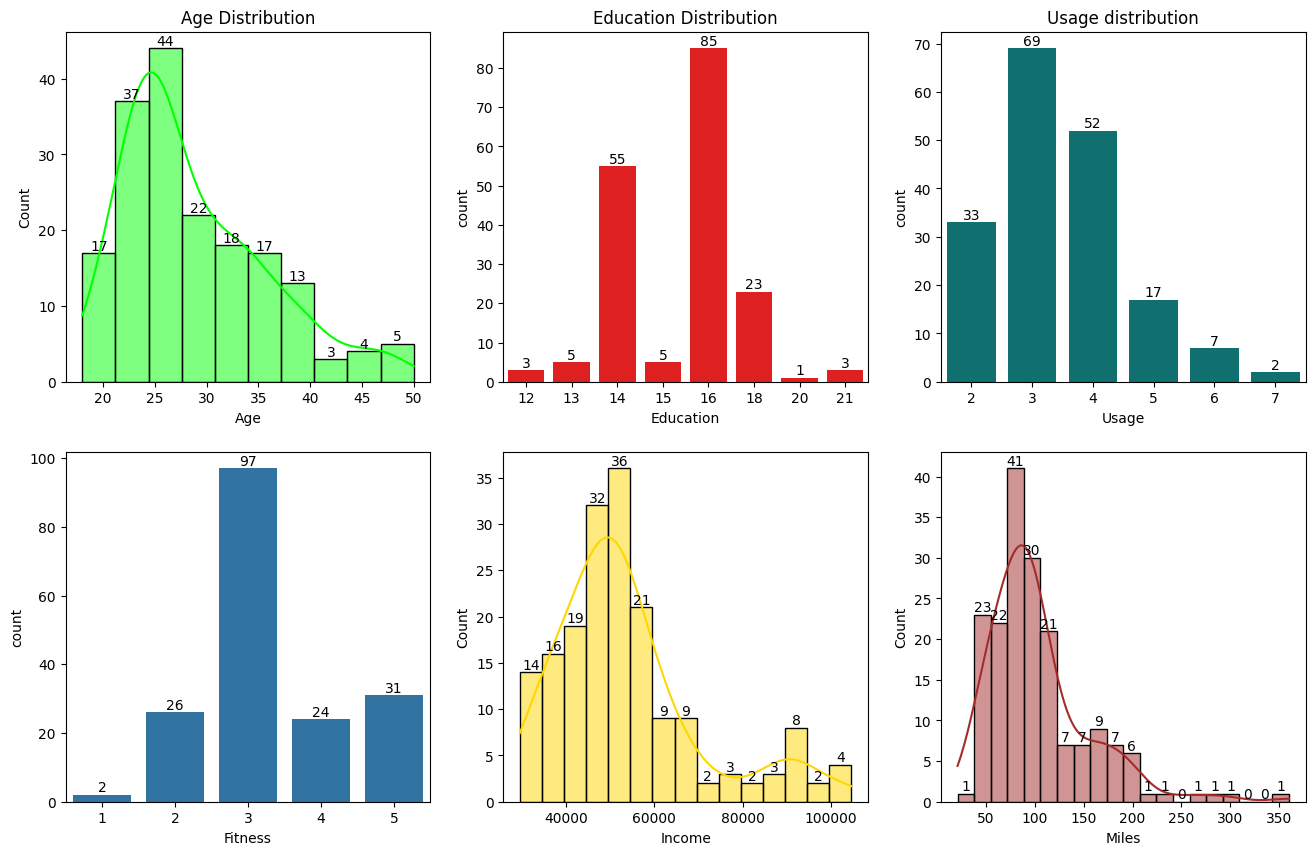

In [ ]:
plt.figure(figsize = (16,10))

# Age Distribution of Customers
plt.subplot(2,3,1)
ax = sns.histplot(atm['Age'], bins = 10, color = 'lime', kde = True)
for container in ax.containers:
  ax.bar_label(container)
plt.title('Age Distribution')

# Education Level Distribution of Customers
plt.subplot(2,3,2)
ax = sns.countplot(data = atm, x = 'Education', color = 'r')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Education Distribution')

# Usage per week Distribution of customers
plt.subplot(2,3,3)
ax = sns.countplot(x = atm['Usage'], color = 'teal')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Usage distribution')

# Fitness Rating Distribution across all customers
plt.subplot(2,3, 4)
ax = sns.countplot(data = atm, x='Fitness')
for container in ax.containers:
  ax.bar_label(container)

# Income Distriobution of customers
plt.subplot(2, 3,5)
ax = sns.histplot(x = atm['Income'], color = 'gold', kde = True, bins = 15)
for container in ax.containers:
  ax.bar_label(container)

# Average number of Miles distribution across customers
plt.subplot(2,3,6)
ax = sns.histplot(x = atm['Miles'], color = 'brown', kde = True)
for container in ax.containers:
  ax.bar_label(container)

plt.show()

In [ ]:
# The above subplots show the distribution analysis for numerical columns
# Age, Usage, Income and Miles distributioins are Right Skewed,
# whereas Fitness Distribution is Left Skewed.

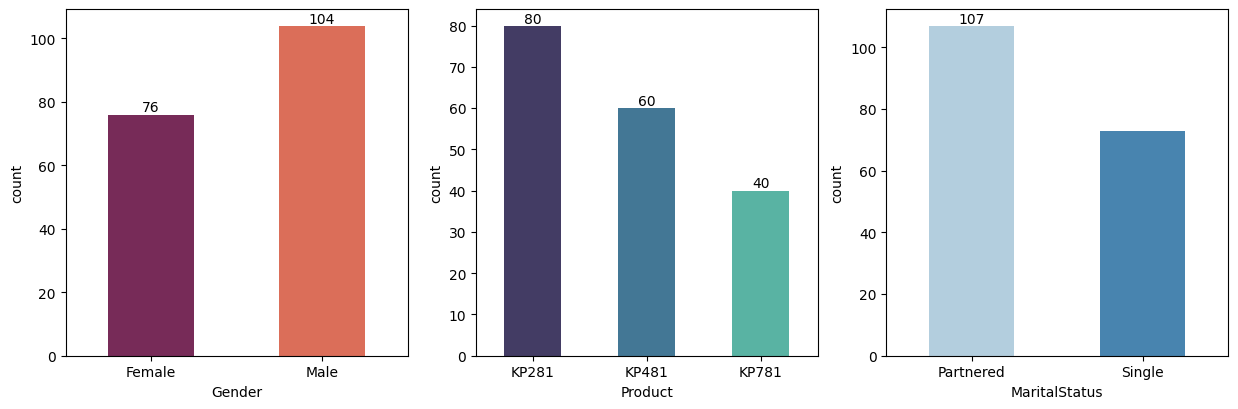

In [ ]:
plt.figure(figsize = (15, 4.5))

plt.subplot(1,3,1)
ax = sns.countplot(x = atm['Gender'], hue = atm['Gender'], palette = 'rocket', width = 0.5)
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(x = atm['Product'], hue = atm['Product'], palette = 'mako', width = 0.5)
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(x = atm['MaritalStatus'], hue = atm['MaritalStatus'], palette = 'Blues', width = 0.5)
for container in ax.containers:
  ax.bar_label(container)

  plt.show()

In [ ]:
# In Products, KP281 with lowest Price, beginner friendly, entry level dominates the treadmmill product category
# Among Marital Status, Partnered dominates among the aerofit Product Users
# And, Male users dominate over female users acroos all category.

### Phase 8: Outliers

In [ ]:
atm.head(1)

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
0,KP281,18,Male,14,Single,3,4,29562,112,Teenage


In [ ]:
# Let us summarize and check mena and median for numerical columnc:

summary = atm[['Age', 'Education', 'Usage', 'Income', 'Fitness', 'Miles']].describe().T

summary[['mean', '50%']]

,mean,50%
Age,28.788889,26.0
Education,15.572222,16.0
Usage,3.455556,3.0
Income,53719.577778,50596.5
Fitness,3.311111,3.0
Miles,103.194444,94.0


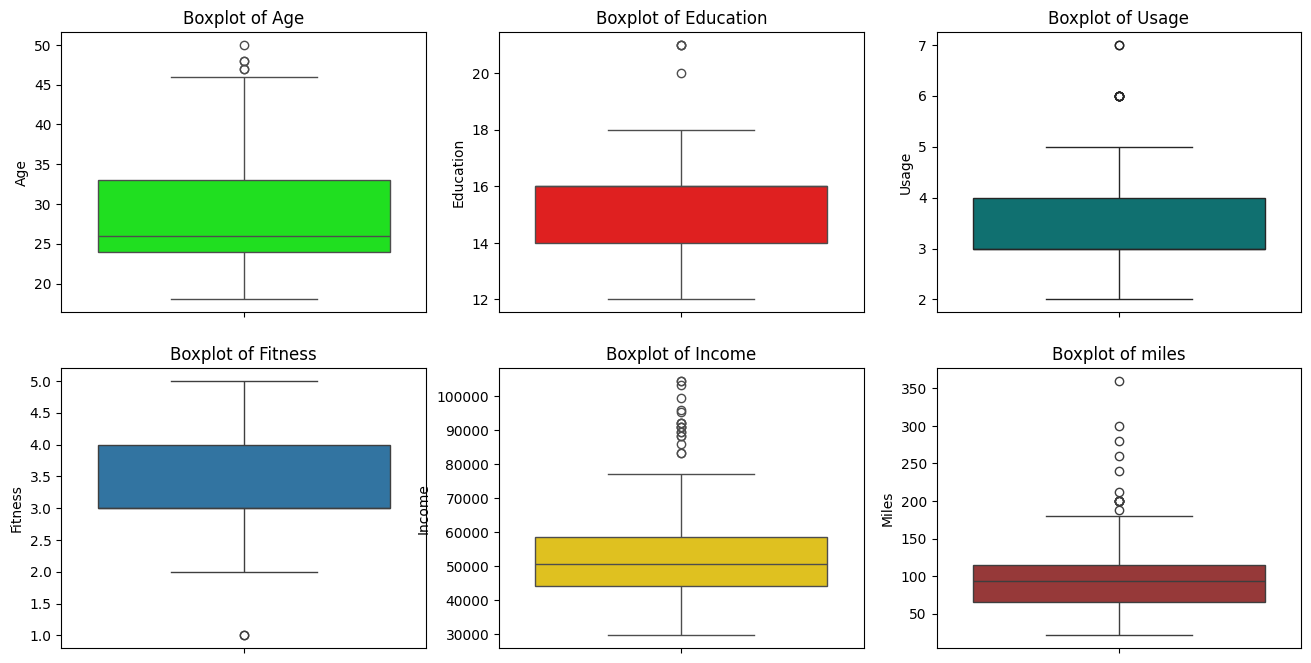

In [ ]:
plt.figure(figsize = (16, 8))

plt.subplot(2,3,1)
sns.boxplot(y = atm['Age'], color = 'lime')
plt.xticks(rotation  = 45)
plt.title('Boxplot of Age')

plt.subplot(2,3,2)
sns.boxplot(y = atm['Education'], color = 'r')
plt.xticks(rotation  = 45)
plt.title('Boxplot of Education')

plt.subplot(2,3,3)
sns.boxplot(y = atm['Usage'], color = 'teal')
plt.xticks(rotation  = 45)
plt.title('Boxplot of Usage')

plt.subplot(2,3,4)
sns.boxplot(y = atm['Fitness'])
plt.xticks(rotation  = 45)
plt.title('Boxplot of Fitness')

plt.subplot(2,3,5)
sns.boxplot(y = atm['Income'], color = 'gold')
plt.xticks(rotation  = 45)
plt.title('Boxplot of Income')

plt.subplot(2,3,6)
sns.boxplot(y = atm['Miles'], color = 'brown')
plt.xticks(rotation  = 45)
plt.title('Boxplot of miles')
plt.show()

In [ ]:
# From the summary tabel and above Boxplots we can see Outliers are prominantly more in Income and Miles.
# The difference between mean and median is greter in Income and Miles.
# Whereas in Age, Education, Usage and Fitness, there are less no. of Outliers
  # which do not affect the skewness of Data relatively as it is with Income and MIles
# Let us detect the Outliers for Income, by further analysis:

In [ ]:
i_s = atm['Income'].describe().T
i_s

,Income
count,180.000000
mean,53719.577778
std,16506.684226
min,29562.000000
25%,44058.750000
50%,50596.500000
75%,58668.000000
max,104581.000000


In [ ]:
atm.sort_values('Income', ascending=False).head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
178,KP781,47,Male,18,Partnered,4,5,104581,120,40s
174,KP781,38,Male,18,Partnered,5,5,104581,150,30s
168,KP781,30,Male,18,Partnered,5,4,103336,160,30s
169,KP781,30,Male,18,Partnered,5,5,99601,150,30s
171,KP781,33,Female,18,Partnered,4,5,95866,200,30s


In [ ]:
# These High Income Values are far gretaer than Mean and Median of Income, due to which there a right skewness in Data as seen in histplots.

In [ ]:
# Let Us identify the outliers using IQR

Q1 = atm['Income'].quantile(0.25)
Q3 = atm['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('IQR:', IQR)
print('Lower Bound:', lower)
print('Upper Bound:', upper)

IQR: 14609.25
Lower Bound: 22144.875
Upper Bound: 80581.875


In [ ]:
# The Potential Outliners:
income_outliers = atm[(atm['Income'] < lower) | (atm['Income'] > upper)]

income_outliers

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group
159,KP781,27,Male,16,Partnered,4,5,83416,160,20s
160,KP781,27,Male,18,Single,4,3,88396,100,20s
161,KP781,27,Male,21,Partnered,4,4,90886,100,20s
162,KP781,28,Female,18,Partnered,6,5,92131,180,20s
164,KP781,28,Male,18,Single,6,5,88396,150,20s
166,KP781,29,Male,14,Partnered,7,5,85906,300,20s
167,KP781,30,Female,16,Partnered,6,5,90886,280,30s
168,KP781,30,Male,18,Partnered,5,4,103336,160,30s
169,KP781,30,Male,18,Partnered,5,5,99601,150,30s
170,KP781,31,Male,16,Partnered,6,5,89641,260,30s


### Phase 9: Bi-Variate Analysis

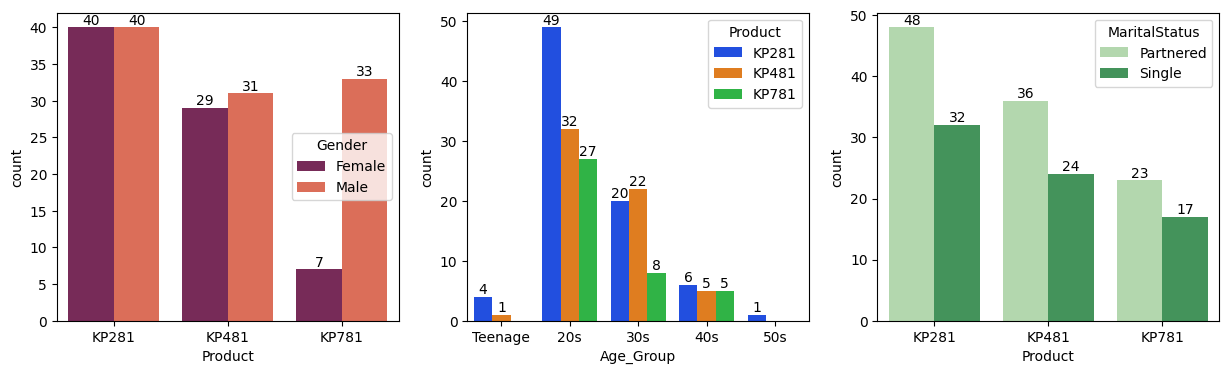

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)



In [ ]:
# In any category of Product, Male buyers/users are dominant than female.
# For KP781 which is the premium model, Male users are almost 4.5 times gretaer than female
# Which suggest advanced features attract Males irrespective of the price of model.

In [ ]:
# Teenagers and Senior are least in customers for aerofit treadmills.
# The Young People who are in their 20s use aerofit treadmills and they prefer entry level model, cheapest i.e KP281.
# Even the premium Treadmill which is KP781, is most preferred by Young Users, beacuse of its Advanced feature, which is mostly probably easy to use for them

In [ ]:
# marital Status does affects the usage of Treadmills in any Product category.
# Partnered Users are dominant across all three categories of product

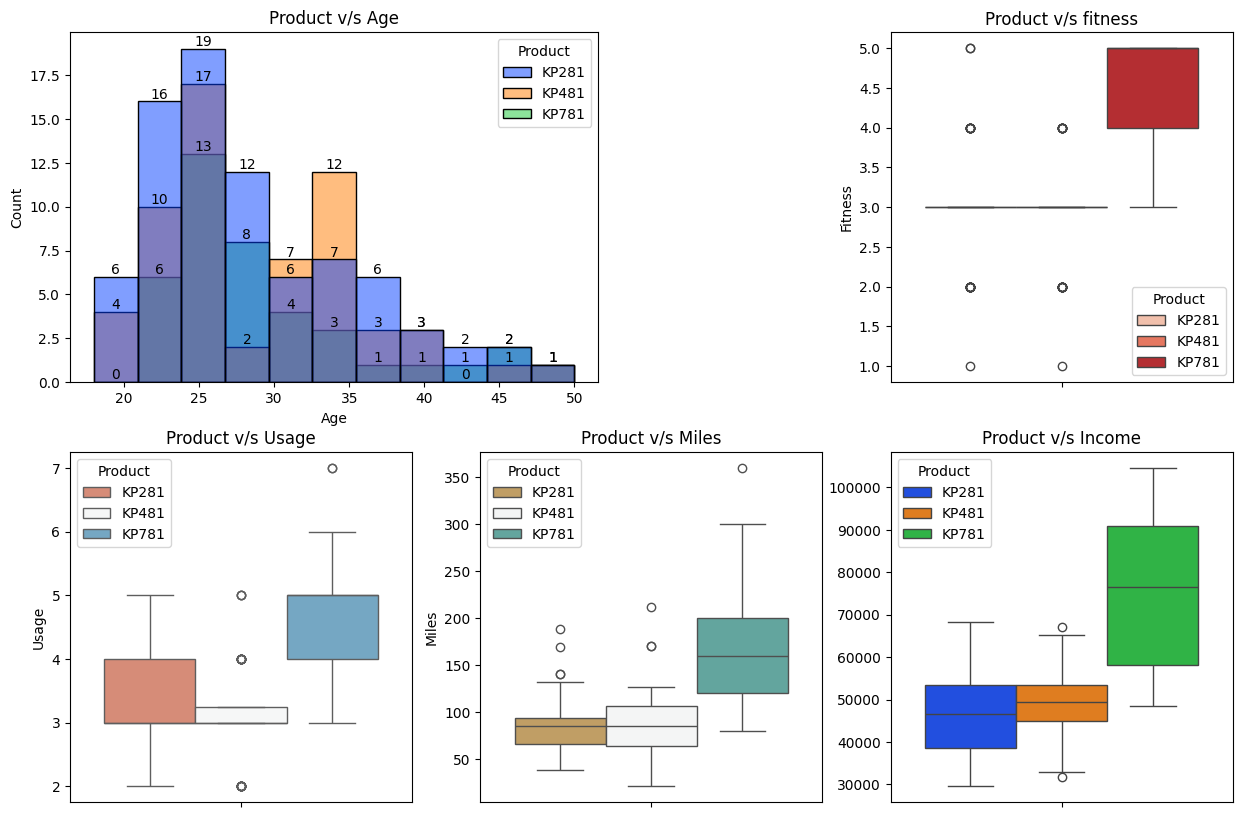

In [ ]:
plt.figure(figsize = (15, 10))

plt.subplot(2,2,1)
ax = sns.histplot(data = atm, x = 'Age', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Product v/s Age')

plt.subplot(2,3,6)
ax = sns.boxplot(data = atm, y = 'Income', hue = 'Product', palette = 'bright')
plt.title('Product v/s Income')

plt.subplot(2,3,3)
ax = sns.boxplot(data = atm, y = 'Fitness', hue = 'Product', palette = 'Reds')
plt.title('Product v/s fitness')

plt.subplot(2,3,4)
ax = sns.boxplot(data = atm, y = 'Usage', hue = 'Product', palette = 'RdBu')
plt.title('Product v/s Usage')

plt.subplot(2,3,5)
ax = sns.boxplot(data = atm, y = 'Miles', hue = 'Product', palette = 'BrBG')
plt.title('Product v/s Miles')

plt.show()

In [ ]:
# Younger Customers 20-30, dominate in buying Premium, advanced treadmill.
# Fitness Level is a enhancer in usage of Products, higher fitness rated customers tend to buy advanced models
# Customers who plan to use products atleast 5 times a week tend to buy advanced model and are ready to spend more money, for hassle free regular usage
# Customers who plan to use products atmost 5 times a week tend to buy entry level model
# The customers expecting to wak/run less than 150 miles/week tend to stick with entry level model, whereas those who expect to walk/run more than 150
  # tend to use a dvanced featuristic model
# customers income directly affects their level of product purchase


### Correlation

In [ ]:
# Let us analyse the numerical columns for thier correlation

numeric_cols = ['Age','Education','Usage','Income','Fitness','Miles']
corr = atm[numeric_cols].corr()
corr

,Age,Education,Usage,Income,Fitness,Miles
Age,1.000000,0.280496,0.015064,0.513414,0.061105,0.036618
Education,0.280496,1.000000,0.395155,0.625827,0.410581,0.307284
Usage,0.015064,0.395155,1.000000,0.519537,0.668606,0.759130
Income,0.513414,0.625827,0.519537,1.000000,0.535005,0.543473
Fitness,0.061105,0.410581,0.668606,0.535005,1.000000,0.785702
Miles,0.036618,0.307284,0.759130,0.543473,0.785702,1.000000


In [ ]:
# Fitness and Miles (0.79); usage and Miles (0.76); Fitness and Usage (0.67); Income and education (0.63) these all have a high positive corelation among them.

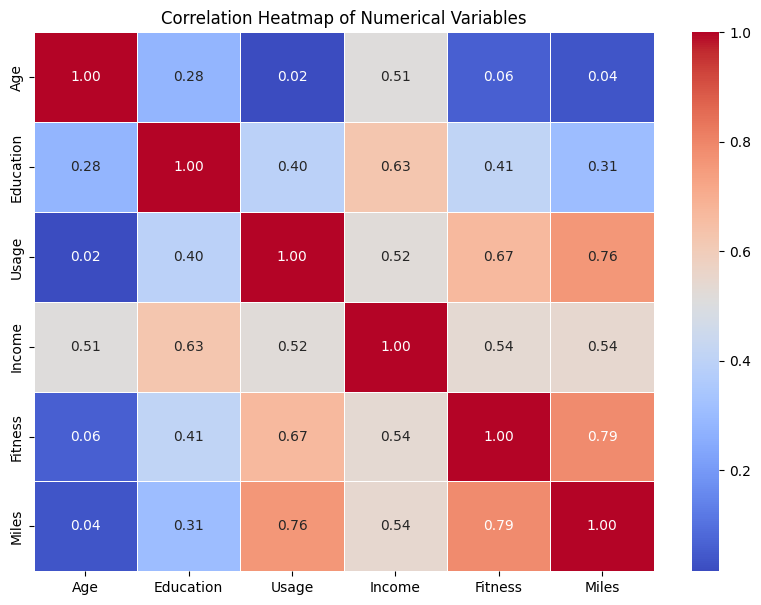

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(corr, annot=True, cmap='coolwarm',fmt='.2f',linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

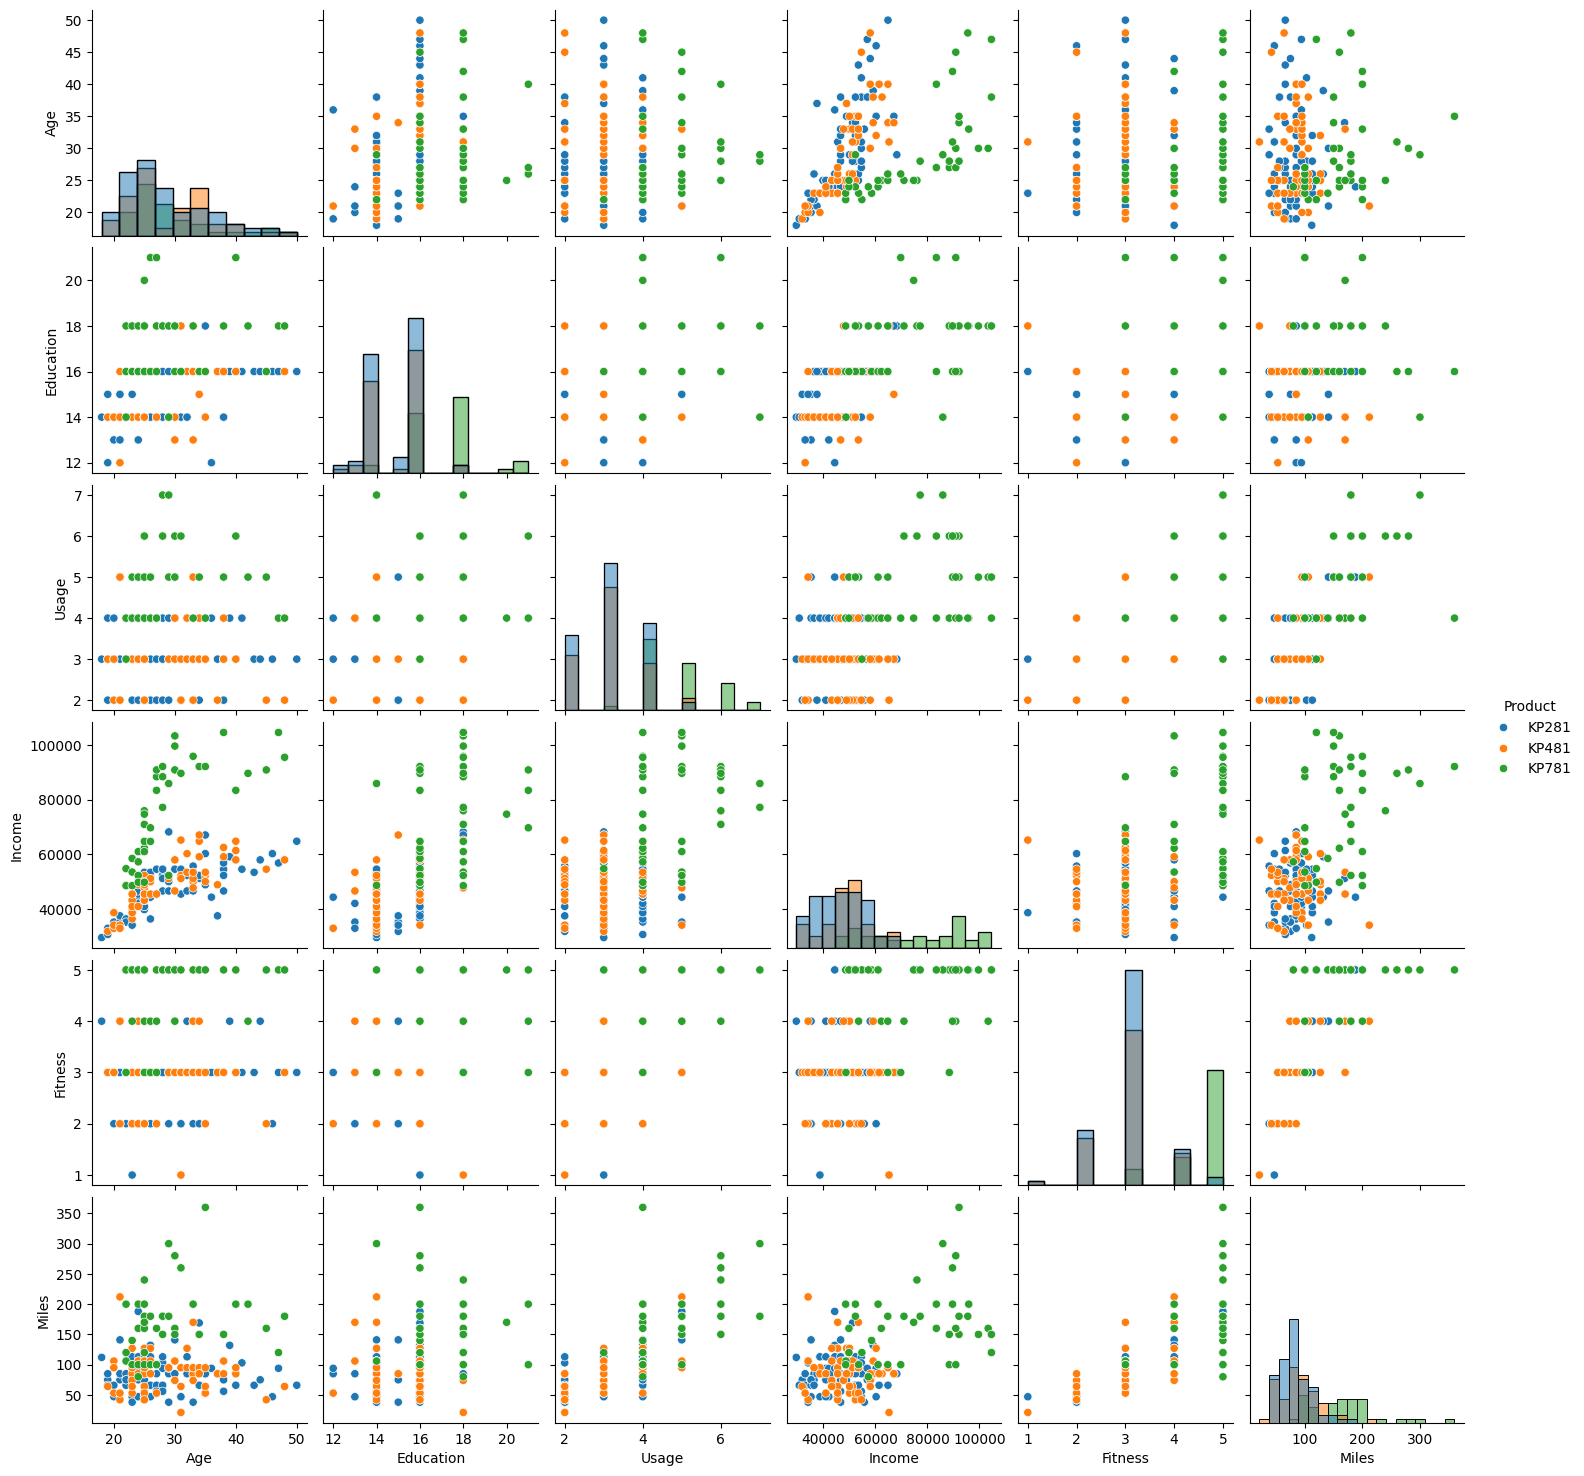

In [ ]:
# Using Pairplot we can deduce more relations:

sns.pairplot(atm, vars=numeric_cols, hue='Product', diag_kind='hist')

plt.show()

In [ ]:
# from fitness and Miles pairplot, we can deduce that Customers havinf high fitness rating intend to run/walk longer miles,
# hence they prefer advanced featuristic KP781 Product.
# Usage and Miles suggest that, customers regularly run/walk each week tend to use advanced treadmill, and this also associated with High Income

### Probability for Products Purchase

In [ ]:
# Let us see Probability of a Male Customer, who dominates advanced Product category Usage, buying a KP781

pd.crosstab([atm['Product']], [atm['Gender']], normalize = True)

Gender,Female,Male
Product,,
KP281,0.222222,0.222222
KP481,0.161111,0.172222
KP781,0.038889,0.183333


In [ ]:
# The above table shows probabiltiy of gender buying a particular product
# Now, given That gender is Male let us find out probability of male  buying KP781

In [ ]:
pd.crosstab([atm['Product']],[atm['Gender']],normalize='columns', margins = True)

Gender,Female,Male,All
Product,,,
KP281,0.526316,0.384615,0.444444
KP481,0.381579,0.298077,0.333333
KP781,0.092105,0.317308,0.222222


In [ ]:
# from the above table, it is evident that:
# for Product KP781 probability of a male buying it is 0.318 or almost 32 %.

Two Way contingency Tables

Product and Gender

In [ ]:


pd.crosstab(atm['Product'], atm['Gender'], normalize = True)

Gender,Female,Male
Product,,
KP281,0.222222,0.222222
KP481,0.161111,0.172222
KP781,0.038889,0.183333


In [ ]:
# Product given Gender
pd.crosstab(atm['Product'], atm['Gender'], normalize = 'columns')

Gender,Female,Male
Product,,
KP281,0.526316,0.384615
KP481,0.381579,0.298077
KP781,0.092105,0.317308


In [ ]:
# gender given Product
pd.crosstab(atm['Product'], atm['Gender'], normalize = 'index')

Gender,Female,Male
Product,,
KP281,0.500000,0.500000
KP481,0.483333,0.516667
KP781,0.175000,0.825000


Product and Marital Status


In [ ]:
pd.crosstab(atm['Product'], atm['MaritalStatus'], normalize = True)

MaritalStatus,Partnered,Single
Product,,
KP281,0.266667,0.177778
KP481,0.200000,0.133333
KP781,0.127778,0.094444


In [ ]:
# Given Product
pd.crosstab(atm['Product'], atm['MaritalStatus'], normalize = 'index')

MaritalStatus,Partnered,Single
Product,,
KP281,0.600,0.400
KP481,0.600,0.400
KP781,0.575,0.425


In [ ]:
# Given Product
pd.crosstab(atm['Product'], atm['MaritalStatus'], normalize = 'columns')

MaritalStatus,Partnered,Single
Product,,
KP281,0.448598,0.438356
KP481,0.336449,0.328767
KP781,0.214953,0.232877


Product and age Group

In [ ]:
pd.crosstab(atm['Product'], atm['Age_Group'], normalize = True)

Age_Group,Teenage,20s,30s,40s,50s
Product,,,,,
KP281,0.022222,0.272222,0.111111,0.033333,0.005556
KP481,0.005556,0.177778,0.122222,0.027778,0.000000
KP781,0.000000,0.150000,0.044444,0.027778,0.000000


In [ ]:
# Given Age group
pd.crosstab(atm['Product'], atm['Age_Group'], normalize = 'columns')

Age_Group,Teenage,20s,30s,40s,50s
Product,,,,,
KP281,0.8,0.453704,0.40,0.3750,1.0
KP481,0.2,0.296296,0.44,0.3125,0.0
KP781,0.0,0.250000,0.16,0.3125,0.0


In [ ]:
# Given Product
pd.crosstab(atm['Product'], atm['Age_Group'], normalize = 'index')

Age_Group,Teenage,20s,30s,40s,50s
Product,,,,,
KP281,0.050000,0.612500,0.250000,0.075000,0.0125
KP481,0.016667,0.533333,0.366667,0.083333,0.0000
KP781,0.000000,0.675000,0.200000,0.125000,0.0000


Product and Fitness

In [ ]:
pd.crosstab(atm['Product'], atm['Fitness'], normalize = True)

Fitness,1,2,3,4,5
Product,,,,,
KP281,0.005556,0.077778,0.300000,0.050000,0.011111
KP481,0.005556,0.066667,0.216667,0.044444,0.000000
KP781,0.000000,0.000000,0.022222,0.038889,0.161111


In [ ]:
# Given Product
pd.crosstab(atm['Product'], atm['Fitness'], normalize = 'index')

Fitness,1,2,3,4,5
Product,,,,,
KP281,0.012500,0.175,0.675,0.112500,0.025
KP481,0.016667,0.200,0.650,0.133333,0.000
KP781,0.000000,0.000,0.100,0.175000,0.725


In [321]:
# Given Fitness
pd.crosstab(atm['Product'], atm['Fitness'], normalize = 'columns')

Fitness,1,2,3,4,5
Product,,,,,
KP281,0.5,0.538462,0.556701,0.375000,0.064516
KP481,0.5,0.461538,0.402062,0.333333,0.000000
KP781,0.0,0.000000,0.041237,0.291667,0.935484


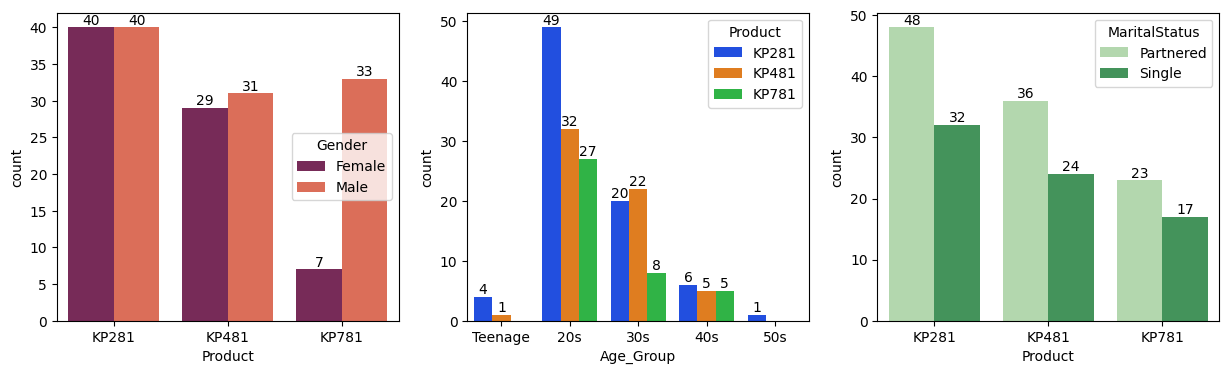

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)

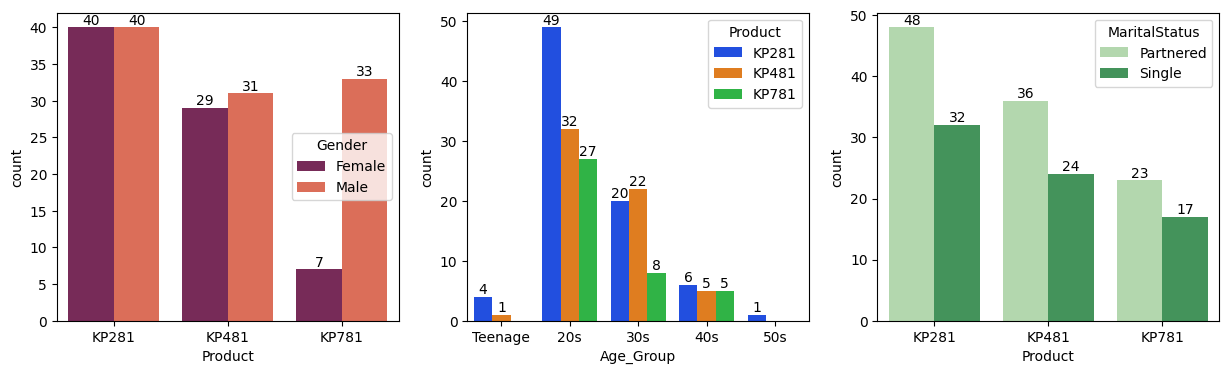

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)

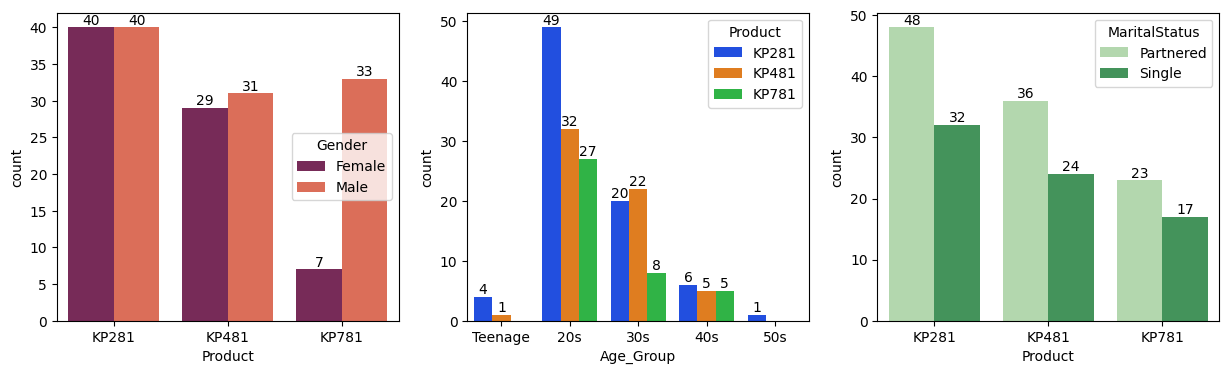

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)

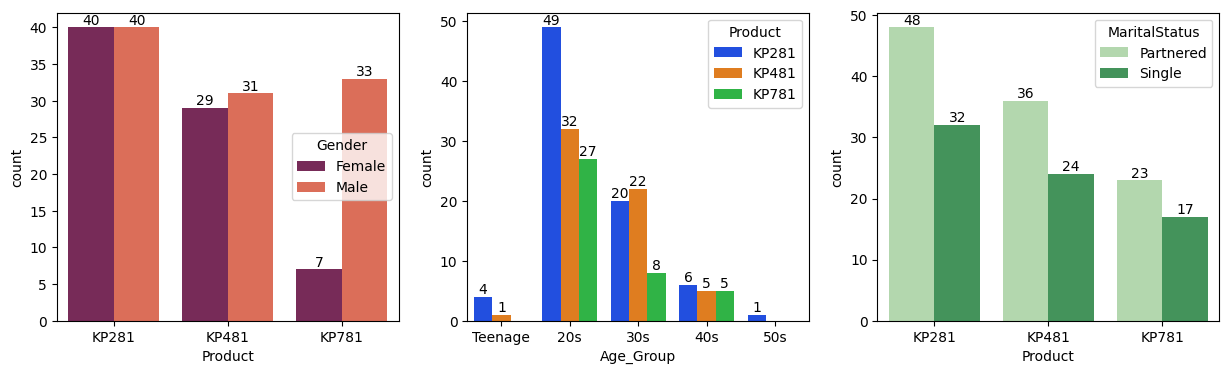

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)

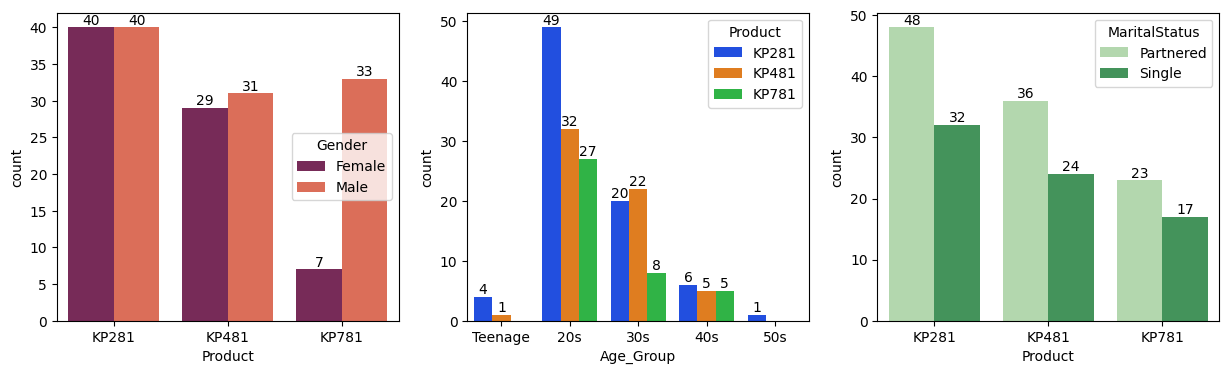

In [ ]:
plt.figure(figsize = (15, 4))

plt.subplot(1,3,1)
ax = sns.countplot(data = atm, x = 'Product', hue = 'Gender', palette = 'rocket')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,2)
ax = sns.countplot(data = atm, x = 'Age_Group', hue = 'Product', palette = 'bright')
for container in ax.containers:
  ax.bar_label(container)

plt.subplot(1,3,3)
ax = sns.countplot(data = atm, x = 'Product', hue = 'MaritalStatus', palette = 'Greens')
for container in ax.containers:
  ax.bar_label(container)